In [4]:
# Import packages for EDA 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Read the CSV file

from pathlib import Path
data_frame = pd.read_csv(Path("..") / "data" / "insurance.csv")

In [6]:
# Display the DataFrame (may be truncated in the notebook output)
data_frame

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Exploratory Data Analysis

step 1 : view data

In [7]:
# Shows number of rows and columns as (rows, columns)
data_frame.shape

(1338, 7)

In [8]:
# Shows the first 5 rows for a quick preview of the data
data_frame.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


step 2 : summary statistics

In [9]:
# Displays column dtypes, non-null counts, and memory usage for the DataFrame
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [10]:
# Shows summary statistics for numeric columns: count, mean, std, min, 25%, 50%, 75%, max
data_frame.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


step 3 : missing value analysis

In [11]:
# Count missing values for each column to determine if imputation or removal is needed
data_frame.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

step 4 : data visualization

In [12]:
# Show all column names to inspect available features and their order
data_frame.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

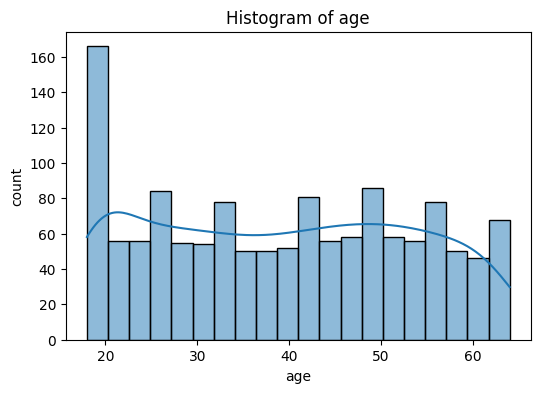

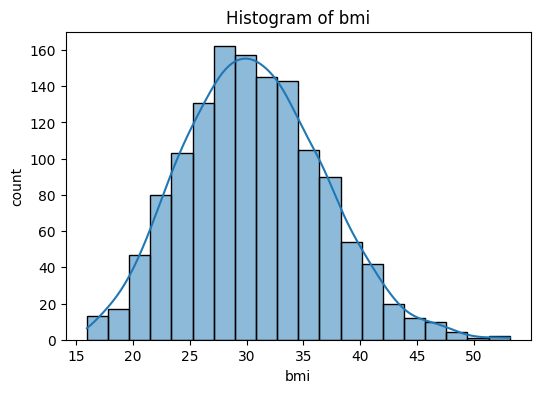

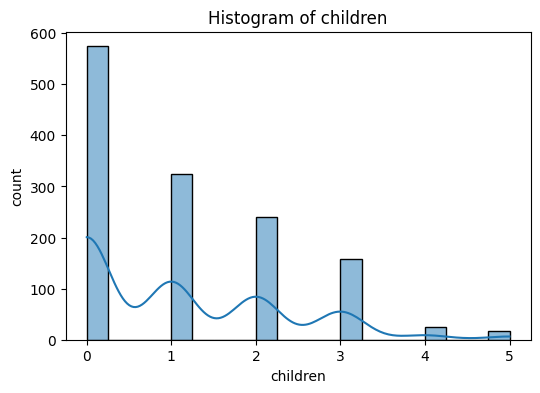

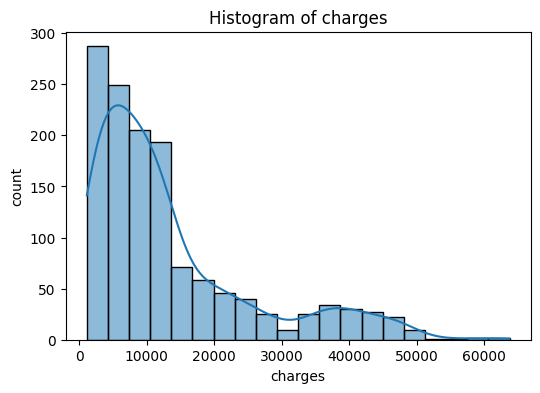

In [13]:
# Plot histograms for selected numeric columns to examine distributions and spot skewness/outliers
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data_frame[col], kde = True, bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

Histogram insights:
- Distribution shape: shows whether data is symmetric, skewed left, or skewed right.
- Central tendency: reveals where most values cluster (approximate mean/median).
- Spread: indicates variability and range of values.
- Modality: shows if distribution is unimodal, bimodal, or multimodal.
- Skewness: shows tail direction which affects mean vs median.
- Outliers: highlights rare extreme values outside the bulk of the data.
- Frequency: shows how often value ranges occur (counts per bin).

<Axes: xlabel='children', ylabel='count'>

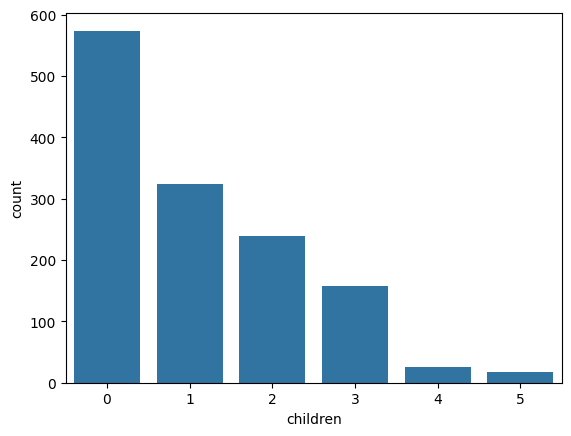

In [14]:
# Countplot showing frequency of each 'children' category
sns.countplot(x = data_frame['children'])

<Axes: xlabel='sex', ylabel='count'>

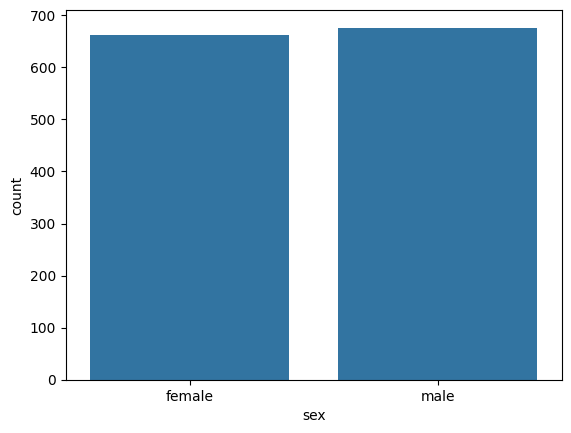

In [15]:
# Countplot showing counts for each sex category
sns.countplot(x = data_frame['sex'])

<Axes: xlabel='smoker', ylabel='count'>

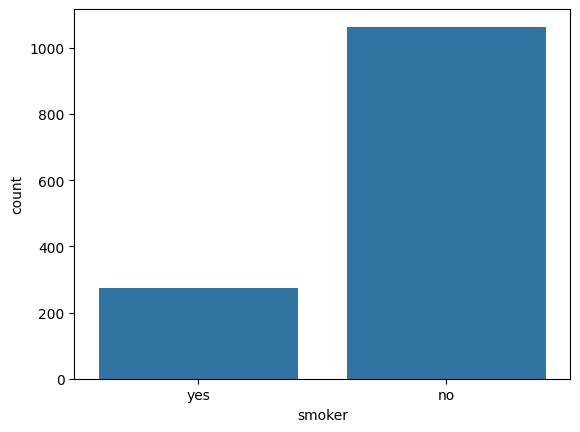

In [16]:
# Countplot comparing smoker vs non-smoker counts
sns.countplot(x = data_frame['smoker'])

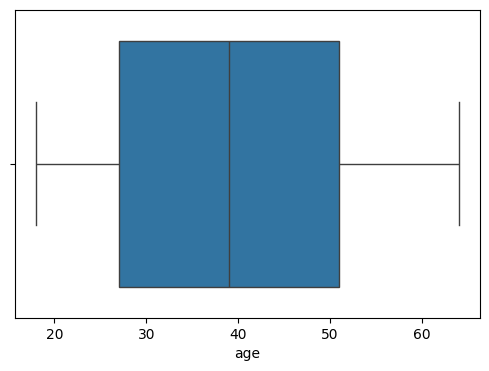

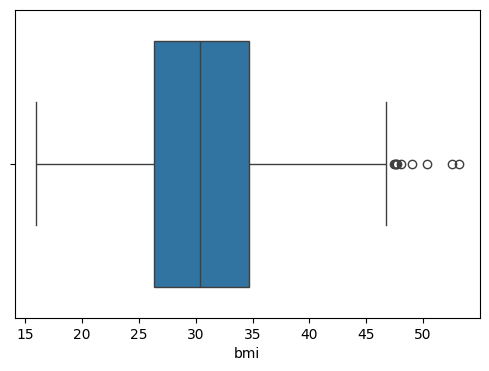

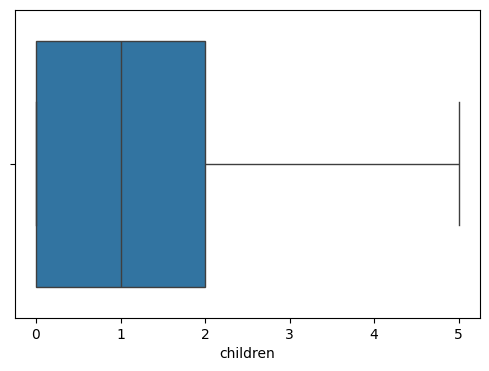

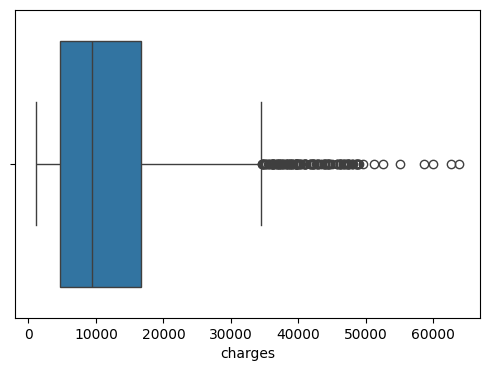

In [17]:
# Boxplots for numeric columns to visualize median, IQR, and possible outliers
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x = data_frame[col])

<Axes: >

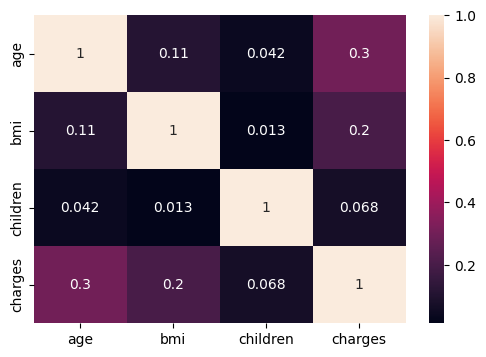

In [18]:
# Heatmap of correlations between numeric features (annotated)
plt.figure(figsize=(6,4))
sns.heatmap(data_frame.corr(numeric_only=True), annot=True)

# Data Cleaning and Preprocessing

In [19]:
# Create a working copy so the original DataFrame stays unchanged
df_cleaned = data_frame.copy()

In [20]:
# Preview the first few rows of the cleaned DataFrame
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
# Check current row and column count before cleaning steps
df_cleaned.shape

(1338, 7)

In [22]:
# Remove duplicate rows in place to avoid repeated records
df_cleaned.drop_duplicates(inplace=True)

In [23]:
# Confirm dataset size after dropping duplicates
df_cleaned.shape

(1337, 7)

In [24]:
# Inspect data types before encoding categorical columns
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [25]:
# Check class balance in the sex column before encoding
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [26]:
# Encode sex as numeric values: male -> 0, female -> 1
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female": 1})

In [27]:
# Verify the DataFrame after sex encoding
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [28]:
# Check class balance in the smoker column before encoding
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [29]:
# Encode smoker status as numeric values: no -> 0, yes -> 1
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no": 0, "yes": 1})

In [30]:
# Verify the DataFrame after smoker encoding
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [31]:
# Rename encoded columns to clearer feature names
df_cleaned.rename(
    columns={
        'sex': 'is_female',
        'smoker': 'is_smoker'
    }, inplace=True
)

In [32]:
# Preview data after renaming encoded feature columns
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [33]:
# Check category frequency for region before one-hot encoding
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [34]:
# One-hot encode region and drop one reference category to avoid multicollinearity
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [35]:
# Convert boolean dummy columns to integer type for modeling compatibility
df_cleaned = df_cleaned.astype(int)

In [36]:
# Preview final cleaned and encoded dataset
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


<Axes: >

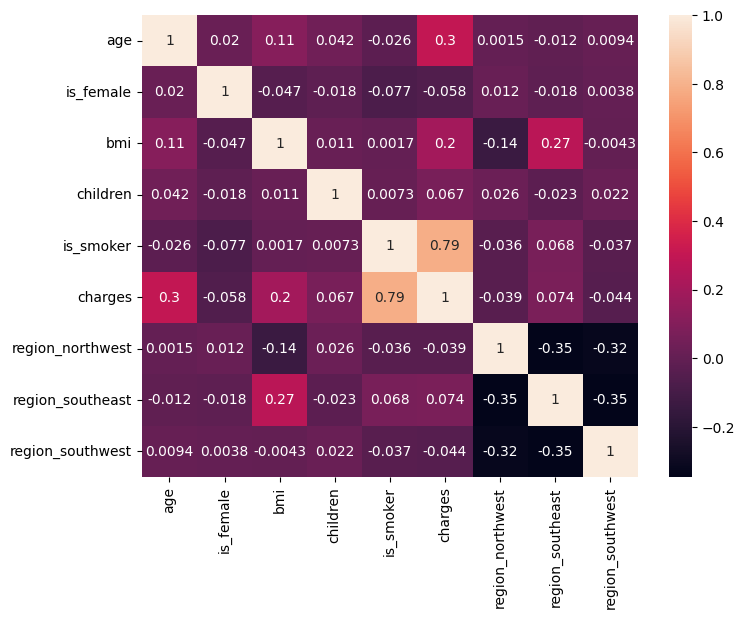

In [37]:
# Visualize correlations in the cleaned dataset to inspect feature relationships
plt.figure(figsize=(8,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True)

Final insights from the correlation heatmap:
- `is_smoker` has the strongest relationship with `charges` (about 0.79), so smoking status is the most important driver of insurance cost in this dataset.
- `age` has a moderate positive relationship with `charges` (about 0.30), indicating charges tend to increase with age.
- `bmi` has a mild positive relationship with `charges` (about 0.20), suggesting higher BMI is associated with somewhat higher charges.
- `children` has a very weak positive relationship with `charges` (about 0.07), so its direct impact appears limited.
- `is_female` has near-zero relationship with `charges` (about -0.06), indicating little direct linear effect after encoding.
- Region dummy columns have weak direct relationships with `charges` (roughly between -0.04 and 0.07), so region alone is not a strong linear predictor here.
- Correlation among region dummy columns is negative by design (around -0.32 to -0.35) because one-hot encoded categories are mutually exclusive.
- There is no severe multicollinearity among the main non-region predictors (`age`, `bmi`, `children`, `is_smoker`, `is_female`), which is good for linear modeling.

# Feature Engineering and Extraction

In [38]:
# Create BMI risk bands to capture non-linear health impact on charges
# Binning converts a continuous variable into interpretable clinical categories.
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


In [39]:
# Quick check that new engineered columns were added correctly
# Early preview helps catch feature-creation errors before downstream steps.
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


In [40]:
# One-hot encode BMI categories and convert booleans to numeric integers for modeling
# One-hot encoding avoids imposing false order across category levels.
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [41]:
# Standardize continuous features so they are on a comparable scale
# Standardization improves optimization stability for many ML algorithms.
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scalar = StandardScaler()
df_cleaned[cols] = scalar.fit_transform(df_cleaned[cols])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [42]:
# Rank selected features by linear association strength with charges using Pearson correlation
# Pearson captures linear relationship direction and magnitude in [-1, 1].
from scipy.stats import pearsonr

selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlation.items()), columns = ['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_Normal,-0.104042


In [43]:
# Define categorical engineered features for chi-square relevance testing
# Keeping this list explicit makes feature-testing reproducible and auditable.
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [44]:
# Use chi-square tests to evaluate categorical feature association with binned charges
# p-value < alpha suggests the feature and target bins are statistically dependent.
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [45]:
# Build the final modeling dataset using selected important features and target
# This reduces noise by keeping only features supported by EDA and tests.
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]
final_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
